# Baseline ML-Propensity Models - Classification Approach
---

## Binary Classification Framework - Multi-Model Comparison

## Purpose
This notebook serves as a **reusable template** for binary classification problems. It's designed to accept any post-feature-engineering dataset and automatically benchmark four ML algorithms with minimal configuration, just specify your target variable and optional parameters.

**Current Example**: Churn propensity modeling (58.1% positive class)

## Key Features
* **Plug-and-Play Architecture**: Works with any binary classification dataset after feature engineering
* **Automated Feature Selection**: SelectFromModel with configurable threshold
* **Hyperparameter Optimization**: Optuna with TPE sampler, early pruning, and parallel trials
* **Rigorous Validation**: 5-fold Stratified CV optimizing F1-score
* **Threshold Calibration**: Optimal decision boundary tuned on precision-recall curve
* **Production-Ready Metrics**: Precision, Recall, F1, AUC-ROC, AU-PR, Accuracy
* **Model Explainability**: Native feature importance + SHAP value analysis

## Models Benchmarked
1. **XGBoost** - Gradient boosting with depth/rate tuning
2. **LightGBM** - Leaf-wise gradient boosting
3. **Decision Tree** - Interpretable classifier with pruning
4. **Logistic Regression** - ElasticNet (L1+L2 regularization)

## Output
Automated ranking by **Test F1-Score** with comprehensive performance dashboard, optimal hyperparameters, and actionable recommendations.

---
**Roadmap**: Additional algorithms will be added in future iterations to expand the benchmarking suite.

## Main imports
---

In [0]:
%pip install -q xgboost lightgbm shap optuna

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix
)
import shap
import optuna

## Data reading
---

In [0]:
path = "workspace.personal_playground.ecommerce_data_cleaned"
df   = spark.table(path).toPandas()

In [0]:
df.head()

,customer_id,age,subscription_type,tenure_months,monthly_charges,total_sessions,support_tickets,last_login_days,referral_bonus_used,churn,expected_ltv,gender_M,gender_Other,region_North,region_South,region_West,device_type_Mobile,device_type_Tablet
0,1,0.422560,1.0,0.880503,1.667029,-0.398513,-1.158004,1.672489,1,0,1811.230169,1,0,0,1,0,0,0
1,2,1.156881,2.0,-1.659555,-1.284442,0.266831,1.618682,0.287269,1,1,428.055423,1,0,0,1,0,0,1
2,3,-0.142303,0.0,0.733961,0.404791,-1.445045,0.924510,-0.520776,1,1,1149.288576,0,0,0,0,1,0,1
3,4,-0.933111,2.0,0.147794,0.949968,0.654949,0.924510,-0.636211,0,1,1625.440249,1,0,1,0,0,0,1
4,5,0.000192,1.0,1.417823,1.157023,1.458907,-1.158004,0.171834,1,0,1837.842564,1,0,0,0,0,0,1


In [0]:
#DEFINE YOUR TARGET, TEST SIZE AND ID_COL
random_state = 42
test_size = 0.20
target_col = 'churn'
id_col     = 'customer_id'

cols_to_drop = [target_col, id_col]
X = df.drop(columns=cols_to_drop)
y = df[target_col]

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=random_state
)

print("=" * 70)
print(" GLOBAL TRAIN/TEST SPLIT (Shared Across All Models)")
print("=" * 70)
print(f"Random State:      {random_state}")
print(f"Test Size:         {test_size:.0%}")
print(f"\nTrain Set:         {X_train.shape[0]:,} records | {X_train.shape[1]} features")
print(f"Test Set:          {X_test.shape[0]:,} records | {X_test.shape[1]} features")

num_neg_train = (y_train == 0).sum()
num_pos_train = (y_train == 1).sum()
num_neg_test = (y_test == 0).sum()
num_pos_test = (y_test == 1).sum()

print(f"\nClass Distribution (Train):")
print(f"  - Negative (0):  {num_neg_train:,} ({num_neg_train/len(y_train):.1%})")
print(f"  - Positive (1):  {num_pos_train:,} ({num_pos_train/len(y_train):.1%})")

print(f"\nClass Distribution (Test):")
print(f"  - Negative (0):  {num_neg_test:,} ({num_neg_test/len(y_test):.1%})")
print(f"  - Positive (1):  {num_pos_test:,} ({num_pos_test/len(y_test):.1%})")
print("=" * 70)

 GLOBAL TRAIN/TEST SPLIT (Shared Across All Models)
Random State:      42
Test Size:         20%

Train Set:         160,000 records | 16 features
Test Set:          40,000 records | 16 features

Class Distribution (Train):
  - Negative (0):  67,010 (41.9%)
  - Positive (1):  92,990 (58.1%)

Class Distribution (Test):
  - Negative (0):  16,752 (41.9%)
  - Positive (1):  23,248 (58.1%)


## XGBoost
---

In [0]:
def fit_xgb_churn_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    df: pd.DataFrame,
    target_col: str = None,
    id_col: str = None,
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    random_state: int = 42
) -> dict:
    

    # Use global variables if not provided
    if target_col is None:
        target_col = globals().get('target_col', 'churn')
    if id_col is None:
        id_col = globals().get('id_col', 'customer_id')
    
    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    scale_pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Calculated scale_pos_weight ratio: {scale_pos_weight:.3f}")

    # MODEL PIPELINE 
    xgb_base = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='aucpr',
        n_jobs=-1
    )

    selector = SelectFromModel(
        estimator=xgb_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('xgb', xgb_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
            'max_depth': trial.suggest_categorical('max_depth', [3, 5, 7, 9]),
            'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
            'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),
            'min_child_weight': trial.suggest_categorical('min_child_weight', [1, 3, 5]),
            'gamma': trial.suggest_categorical('gamma', [0, 0.1, 0.2])
        }
        
        # CREATE MODEL
        model = xgb.XGBClassifier(
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            eval_metric='aucpr',
            n_jobs=-1,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('xgb', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='xgboost_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 10}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='aucpr',
        n_jobs=-1,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('xgb', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['xgb']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    selected_mask = best_selector.get_support()
    selected_features = X.columns[selected_mask].tolist()
    removed_features = X.columns[~selected_mask].tolist()

    print("\n")
    print(" 3. FEATURE SELECTION")
    print("=" * 60)
    print(f" - Initial Predictor Features: {X.shape[1]}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # TRANSFORMATION
    X_train_sel = pd.DataFrame(best_selector.transform(X_train), columns=selected_features, index=X_train.index)
    X_test_sel = pd.DataFrame(best_selector.transform(X_test), columns=selected_features, index=X_test.index)

    # PROBABILITIES AND OPTIMAL THRESHOLD
    probs_train = best_model.predict_proba(X_train_sel)[:, 1]
    probs_test = best_model.predict_proba(X_test_sel)[:, 1]

    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. EVALUATION AND OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score: {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary ---")
    print(metrics_df.round(4))

    # VISUALIZATIONS: ROC, PR CURVES AND CONFUSION MATRIX
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - XGBoost (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - XGBoost (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - XGBoost (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('evaluation_metrics_summary.png', dpi=150)
    plt.show()

    # FEATURE IMPORTANCE VISUALIZATIONS (WEIGHT AND GAIN)
    booster = best_model.get_booster()
    booster.feature_names = selected_features

    weight_imp = pd.Series(booster.get_score(importance_type='weight'), name='Weight')
    gain_imp = pd.Series(booster.get_score(importance_type='gain'), name='Gain')

    feat_imp = pd.DataFrame({'Weight': weight_imp, 'Gain': gain_imp}).fillna(0)
    feat_imp.index.name = 'Feature'

    fig_imp, axes_imp = plt.subplots(1, 2, figsize=(14, 5))
    feat_imp.sort_values(by='Weight', ascending=True)['Weight'].tail(15).plot(
        kind='barh', ax=axes_imp[0], color='skyblue'
    )
    axes_imp[0].set_title('XGBoost Feature Relevance (Weight / Freq)')
    axes_imp[0].set_xlabel('Split Frequency')

    feat_imp.sort_values(by='Gain', ascending=True)['Gain'].tail(15).plot(
        kind='barh', ax=axes_imp[1], color='salmon'
    )
    axes_imp[1].set_title('XGBoost Information Gain')
    axes_imp[1].set_xlabel('Mean Gain')
    plt.tight_layout()
    plt.savefig('xgb_native_feature_importance.png', dpi=150)
    plt.show()

    # 9. SHAP VISUALIZATIONS
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    plt.figure(figsize=(10, 6))
    plt.title('XGBoost SHAP Summary Plot (Selected Features)', fontsize=12)
    shap.plots.beeswarm(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=150)
    plt.show()
    
    print("\n")
    plt.figure(figsize=(10, 6))
    plt.title('XGBoost SHAP Feature Importance (Bar Plot)', fontsize=12)
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_bar_importance.png', dpi=150)
    plt.show()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-12 09:43:47,932] A new study created in memory with name: xgboost_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Calculated scale_pos_weight ratio: 0.721


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-12 09:44:08,544] Trial 0 finished with value: 0.8416821751981626 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-12 09:44:53,882] Trial 1 finished with value: 0.835306967799046 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-12 09:45:19,838] Trial 2 finished with value: 0.8408405993874656 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'gamma': 0.1}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-12 09:45:33,987] Trial 3 finished with value: 0.8409665862384694 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'subsamp

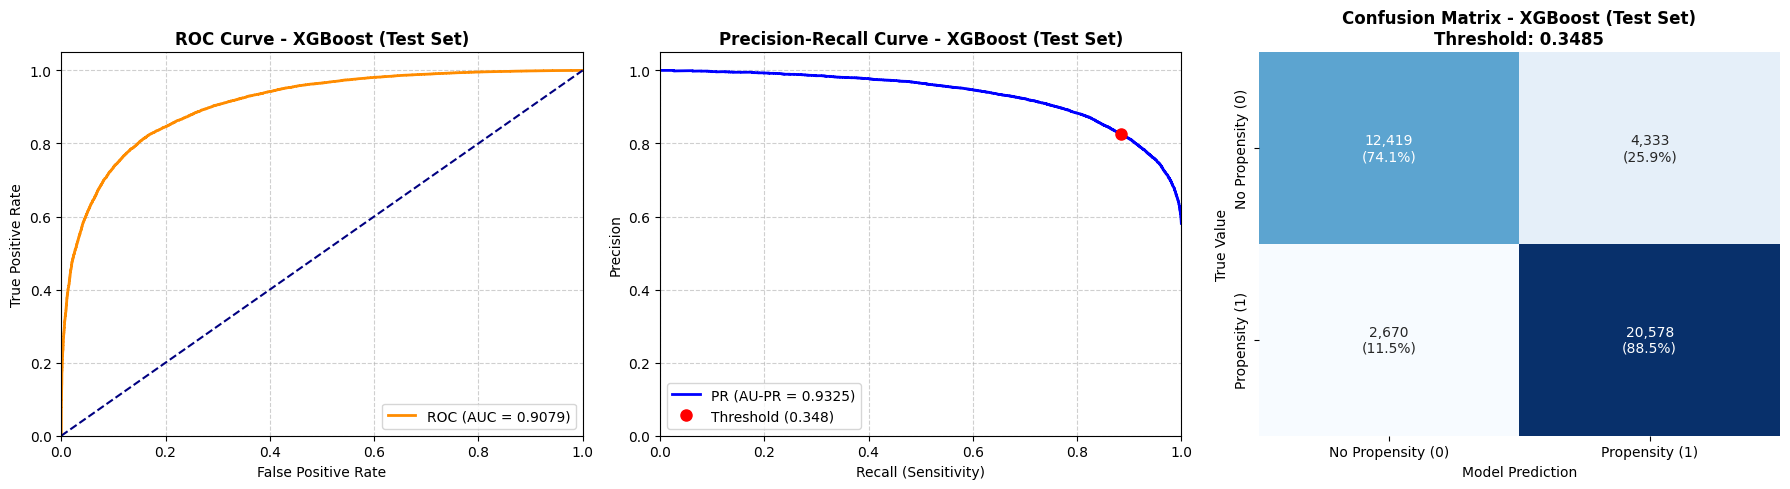

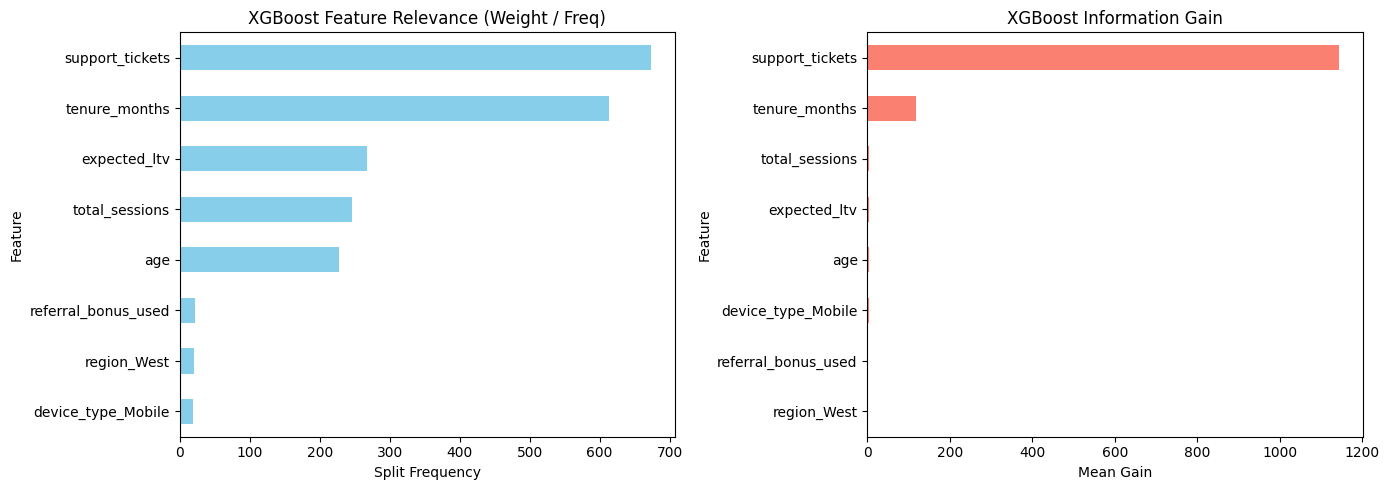

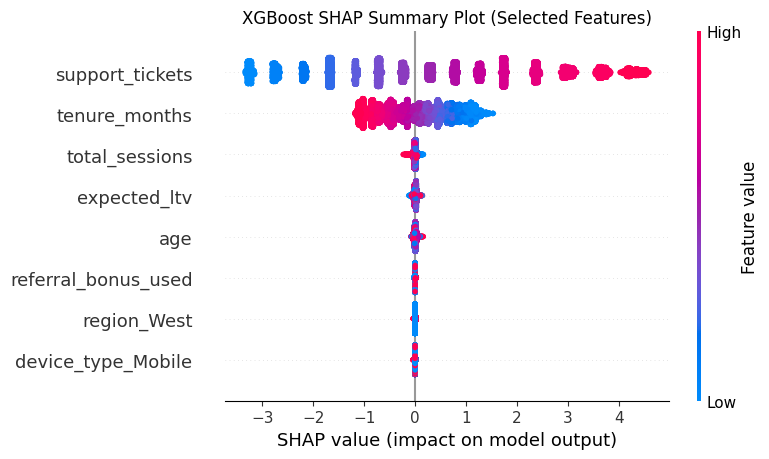

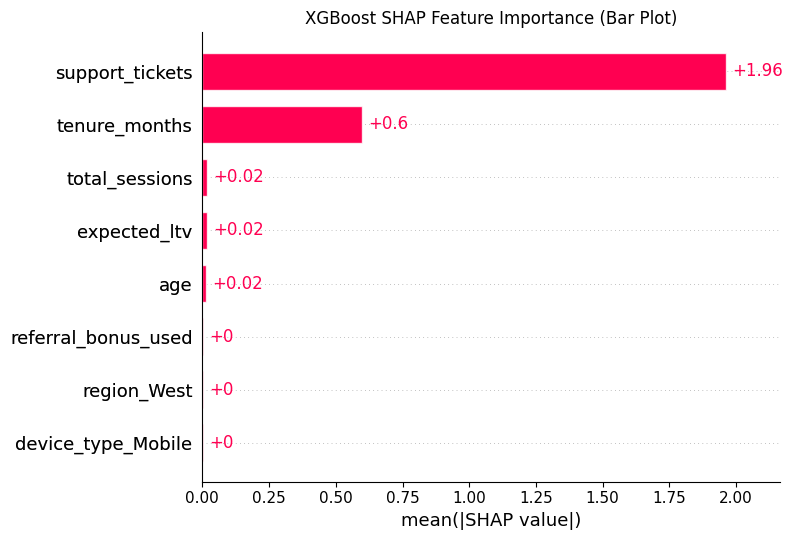

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,0.99585694,1
183691,1,0.9788205,1
190416,1,0.9886746,1
97505,1,0.8862061,1
177223,0,0.79746246,1
181100,1,0.6159504,1
3513,1,0.578627,1
118791,1,0.98395765,1
129846,0,0.07117139,0
115,1,0.82345986,1


In [0]:
results_xgboost = fit_xgb_churn_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    df=df,
    n_iter_search=20
)

df_test_predictions = results_xgboost['df_test_results']
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[[id_col, target_col, pred_prob_col, pred_label_col]].head(20))

## LightGBM
---

In [0]:
def fit_lgb_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    df: pd.DataFrame,
    target_col: str = None,
    id_col: str = None,
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    random_state: int = 42
) -> dict:
    
  
    # Use global variables if not provided
    if target_col is None:
        target_col = globals().get('target_col', 'churn')
    if id_col is None:
        id_col = globals().get('id_col', 'customer_id')
    
    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    scale_pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Calculated scale_pos_weight ratio: {scale_pos_weight:.3f}")

    # MODEL PIPELINE 
    lgb_base = lgb.LGBMClassifier(
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )

    selector = SelectFromModel(
        estimator=lgb_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('lgb', lgb_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
            'num_leaves': trial.suggest_categorical('num_leaves', [15, 31, 63, 127]),
            'max_depth': trial.suggest_categorical('max_depth', [-1, 3, 5, 7, 9]),
            'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
            'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),
            'min_child_samples': trial.suggest_categorical('min_child_samples', [10, 20, 30, 50]),
            'reg_alpha': trial.suggest_categorical('reg_alpha', [0.0, 0.1, 1.0]),
            'reg_lambda': trial.suggest_categorical('reg_lambda', [0.0, 0.1, 1.0])
        }
        
        # CREATE MODEL
        model = lgb.LGBMClassifier(
            objective='binary',
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('lgb', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='lightgbm_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 60}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = lgb.LGBMClassifier(
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('lgb', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['lgb']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    selected_mask = best_selector.get_support()
    selected_features = X.columns[selected_mask].tolist()
    removed_features = X.columns[~selected_mask].tolist()

    print("\n")
    print(" 3. FEATURE SELECTION")
    print("=" * 60)
    print(f" - Initial Predictor Features: {X.shape[1]}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # TRANSFORMATION
    X_train_sel = pd.DataFrame(best_selector.transform(X_train), columns=selected_features, index=X_train.index)
    X_test_sel = pd.DataFrame(best_selector.transform(X_test), columns=selected_features, index=X_test.index)

    # PROBABILITIES AND OPTIMAL THRESHOLD
    probs_train = best_model.predict_proba(X_train_sel)[:, 1]
    probs_test = best_model.predict_proba(X_test_sel)[:, 1]

    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n" + "=" * 60)
    print(" 4. EVALUATION AND OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score: {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary ---")
    print(metrics_df.round(4))

    # VISUALIZATIONS: ROC, PR CURVES AND CONFUSION MATRIX
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - LightGBM (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - LightGBM (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - LightGBM (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('evaluation_metrics_summary.png', dpi=150)
    plt.show()

    # FEATURE IMPORTANCE VISUALIZATIONS (SPLIT / WEIGHT AND GAIN)
    booster = best_model.booster_
    
    split_imp = pd.Series(booster.feature_importance(importance_type='split'), index=selected_features, name='Weight')
    gain_imp = pd.Series(booster.feature_importance(importance_type='gain'), index=selected_features, name='Gain')

    feat_imp = pd.DataFrame({'Weight': split_imp, 'Gain': gain_imp}).fillna(0)
    feat_imp.index.name = 'Feature'

    fig_imp, axes_imp = plt.subplots(1, 2, figsize=(14, 5))
    feat_imp.sort_values(by='Weight', ascending=True)['Weight'].tail(15).plot(
        kind='barh', ax=axes_imp[0], color='skyblue'
    )
    axes_imp[0].set_title('LightGBM Feature Relevance (Split Frequency)')
    axes_imp[0].set_xlabel('Split Frequency')

    feat_imp.sort_values(by='Gain', ascending=True)['Gain'].tail(15).plot(
        kind='barh', ax=axes_imp[1], color='salmon'
    )
    axes_imp[1].set_title('LightGBM Information Gain')
    axes_imp[1].set_xlabel('Mean Gain')
    plt.tight_layout()
    plt.savefig('lgb_native_feature_importance.png', dpi=150)
    plt.show()

    # SHAP VISUALIZATIONS
    
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    plt.figure(figsize=(10, 6))
    plt.title('LightGBM SHAP Summary Plot (Selected Features)', fontsize=12)
    shap.plots.beeswarm(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=150)
    plt.show()

    print("\n")


    plt.figure(figsize=(10, 6))
    plt.title('LightGBM SHAP Feature Importance (Bar Plot)', fontsize=12)
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_bar_importance.png', dpi=150)
    plt.show()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-12 09:52:40,649] A new study created in memory with name: lightgbm_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Calculated scale_pos_weight ratio: 0.721


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-12 09:53:12,566] Trial 0 finished with value: 0.8425984231079979 and parameters: {'n_estimators': 200, 'num_leaves': 15, 'max_depth': 9, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 50, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 0.8425984231079979.
[I 2026-08-12 09:53:50,679] Trial 1 finished with value: 0.8409750097365825 and parameters: {'n_estimators': 300, 'num_leaves': 15, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 0.8425984231079979.
[I 2026-08-12 09:54:32,790] Trial 2 finished with value: 0.8416765246842518 and parameters: {'n_estimators': 200, 'num_leaves': 63, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_samples': 30, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 0.8425984231079979.
[I 2026-08-12 09:54:42,63

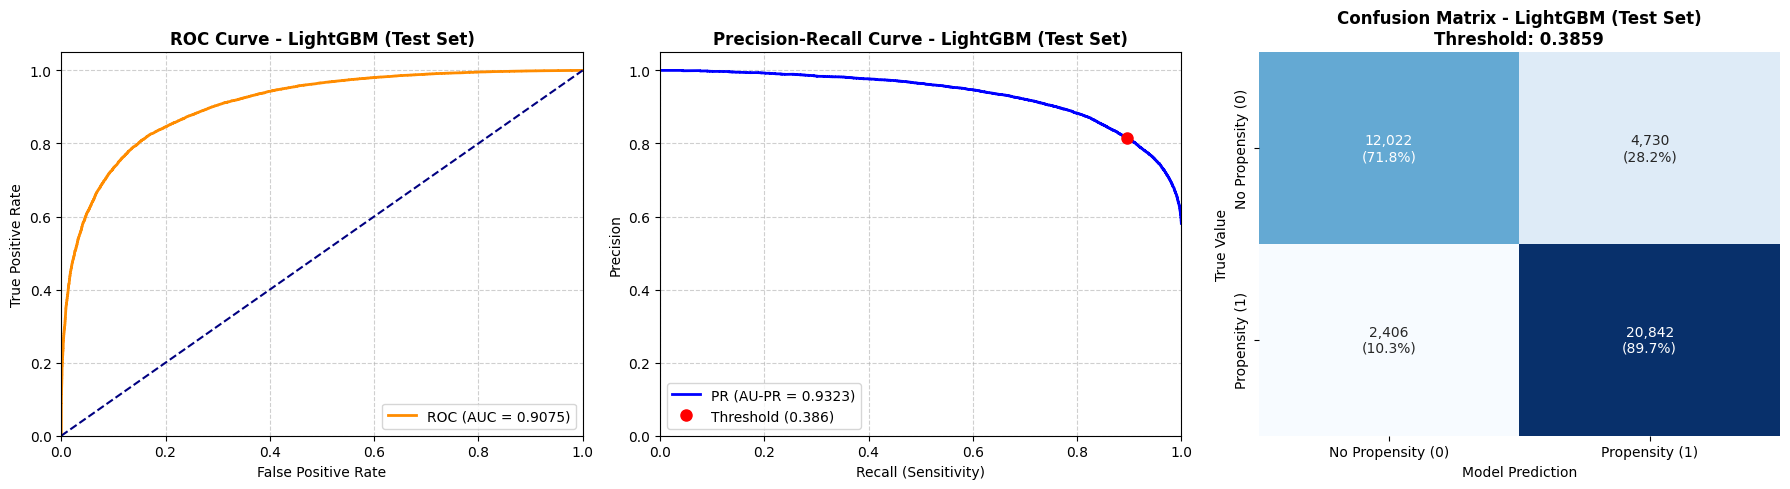

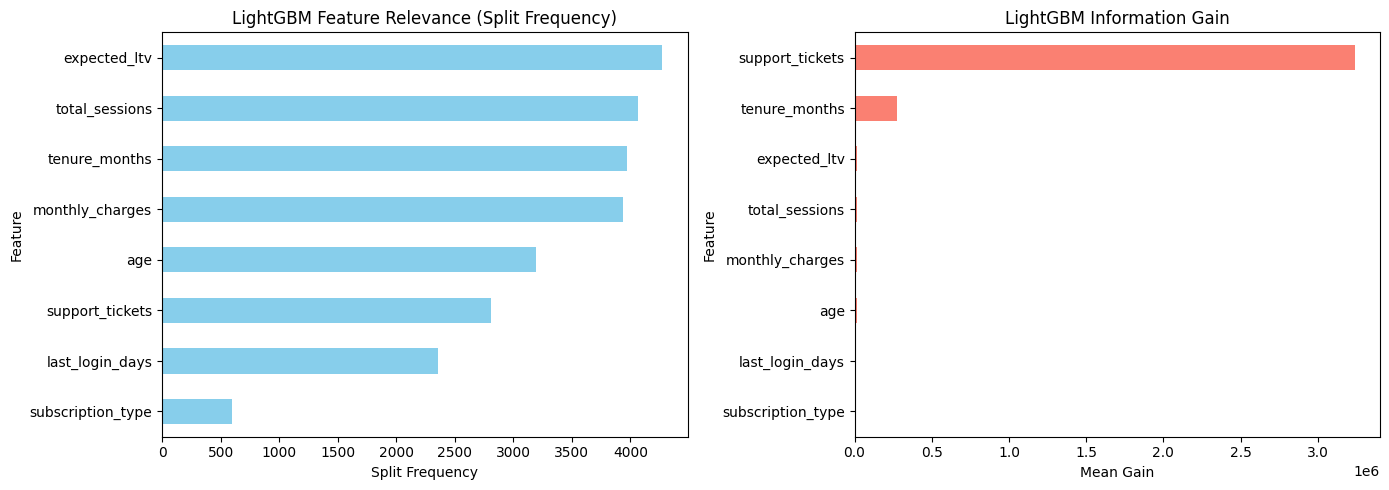

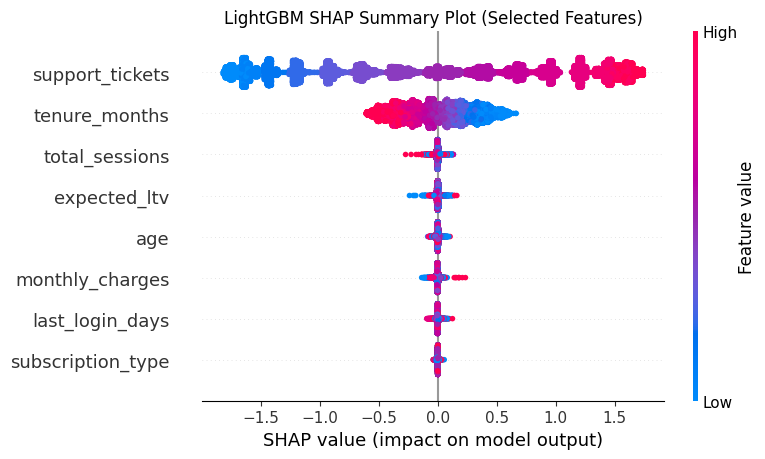

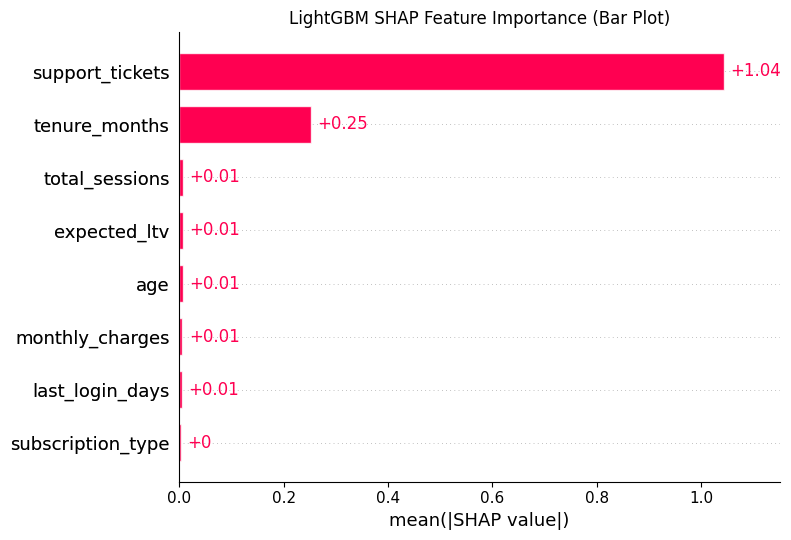

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,0.8806152510228753,1
183691,1,0.8562505388974511,1
190416,1,0.859910049997954,1
97505,1,0.7690251480269298,1
177223,0,0.7226870003992707,1
181100,1,0.5548488507816319,1
3513,1,0.5941784109700396,1
118791,1,0.8749664827421482,1
129846,0,0.19273232322212577,0
115,1,0.7334686968254222,1


In [0]:
results_lgbm = fit_lgb_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    df=df,
    n_iter_search=20
)
 

df_test_predictions = results_lgbm['df_test_results']
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[[id_col, target_col, pred_prob_col, pred_label_col]].head(20))

## Decision Tree
---

In [0]:
def fit_dt_churn_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    df: pd.DataFrame,
    target_col: str = None,
    id_col: str = None,
    class_weight: str | dict | None = 'balanced',
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    max_depth_plot: int | None = 3,
    random_state: int = 42
) -> dict:

    # Use global variables if not provided
    if target_col is None:
        target_col = globals().get('target_col', 'churn')
    if id_col is None:
        id_col = globals().get('id_col', 'customer_id')
    
    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Model Algorithm: Decision Tree Classifier")
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    imbalance_ratio = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Class distribution in Train -> Negative (0): {num_neg:,} | Positive (1): {num_pos:,}")
    print(f"- Calculated imbalance ratio (neg/pos): {imbalance_ratio:.2f}:1")
    print(f"- Decision Tree Class weight strategy: Optimized by Optuna")

    # BASE DECISION TREE MODEL & SELECTOR
    dt_base = DecisionTreeClassifier(
        class_weight=class_weight,
        random_state=random_state
    )

    selector = SelectFromModel(
        estimator=dt_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('dt', dt_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'max_depth': trial.suggest_categorical('max_depth', [3, 4, 5, 6, 8, 10]),
            'min_samples_split': trial.suggest_categorical('min_samples_split', [10, 20, 50, 100]),
            'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [5, 10, 20, 50, 100]),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'ccp_alpha': trial.suggest_categorical('ccp_alpha', [0.0, 0.001, 0.005, 0.01, 0.02]),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
        
        # CREATE MODEL
        model = DecisionTreeClassifier(
            random_state=random_state,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('dt', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='decision_tree_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 5}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = DecisionTreeClassifier(
        random_state=random_state,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('dt', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['dt']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    all_feature_names = X_train.columns.tolist()
    selected_mask = best_selector.get_support()
    selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
    removed_features = [f for f, s in zip(all_feature_names, selected_mask) if not s]

    print("\n")
    print(" 3. FEATURE SELECTION (DECISION TREE IMPORTANCE)")
    print("=" * 60)
    print(f" - Initial Predictor Features: {len(all_feature_names)}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # PROBABILITIES VIA PIPELINE
    probs_train = best_pipeline.predict_proba(X_train)[:, 1]
    probs_test = best_pipeline.predict_proba(X_test)[:, 1]

    # OPTIMAL THRESHOLD
    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. DECISION TREE EVALUATION & OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score (calculated on Train): {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary (Propensity Model - Decision Tree) ---")
    print(metrics_df.round(4))

    # EVALUATION METRICS (ROC, PR, CONFUSION MATRIX)
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Decision Tree (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - Decision Tree (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Decision Tree (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('dt_evaluation_metrics_summary.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 2: DECISION TREE DIAGRAM
    # ==============================================================================
    plt.figure(figsize=(22, 10), dpi=300)
    plot_tree(
        best_model,
        max_depth=max_depth_plot,
        feature_names=selected_features,
        class_names=['No Propensity (0)', 'Propensity (1)'],
        filled=True,
        rounded=True,
        impurity=True,
        proportion=False,
        precision=2,
        fontsize=8
    )
    title_depth = f"First {max_depth_plot} Levels" if max_depth_plot is not None else "Full Tree"
    plt.title(f'Decision Tree Structure ({title_depth})', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('decision_tree_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 3: NATIVE FEATURE IMPORTANCE
    # ==============================================================================
    feat_imp = pd.Series(best_model.feature_importances_, index=selected_features, name='Gini Importance')
    feat_imp = feat_imp.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    feat_imp.tail(15).plot(kind='barh', color='skyblue')
    plt.title('Decision Tree Feature Importance (Gini)', fontsize=12, fontweight='bold')
    plt.xlabel('Gini Importance')
    plt.tight_layout()
    plt.savefig('dt_native_feature_importance.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 4 & 5: SHAP PLOTS
    # ==============================================================================
    X_test_sel = pd.DataFrame(
        best_selector.transform(X_test),
        columns=selected_features,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    if len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

    # SHAP Beeswarm
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values_to_plot, show=False)
    plt.title('Decision Tree - SHAP Summary Plot', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('dt_shap_summary_plot.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")
    
    # SHAP Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values_to_plot, show=False)
    plt.title('Decision Tree - SHAP Feature Importance (Bar Plot)', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('dt_shap_bar_importance.png', dpi=150)
    plt.show()
    plt.close()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-12 05:33:58,753] A new study created in memory with name: decision_tree_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Model Algorithm: Decision Tree Classifier
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Class distribution in Train -> Negative (0): 67,010 | Positive (1): 92,990
- Calculated imbalance ratio (neg/pos): 0.72:1
- Decision Tree Class weight strategy: Optimized by Optuna


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-12 05:34:01,081] Trial 0 finished with value: 0.8222270962335667 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0, 'class_weight': None}. Best is trial 0 with value: 0.8222270962335667.
[I 2026-08-12 05:34:03,603] Trial 1 finished with value: 0.8030020426945127 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 100, 'max_features': 'log2', 'ccp_alpha': 0.01, 'class_weight': None}. Best is trial 0 with value: 0.8222270962335667.
[I 2026-08-12 05:34:11,168] Trial 2 finished with value: 0.827880760537899 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.005, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.827880760537899.
[I 2026-08-12 05:34:13,684] Trial 3 finished with value: 0.6976816056712678 and parameters: {'criterion': '

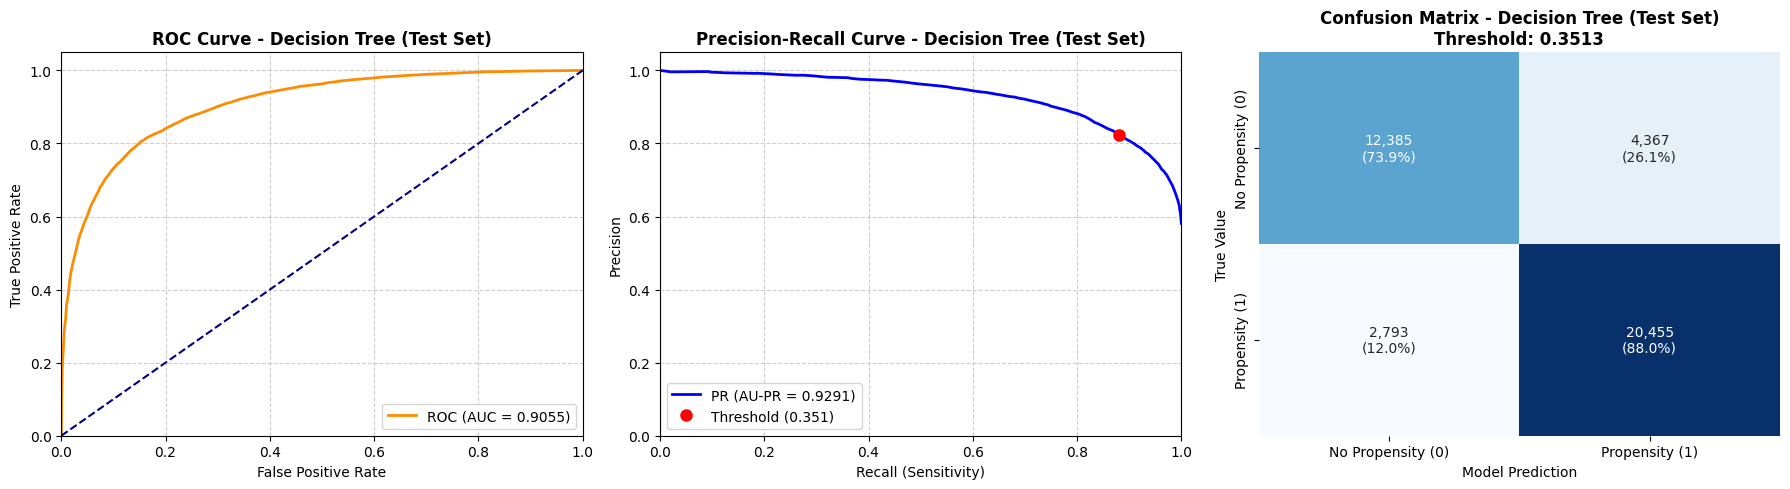

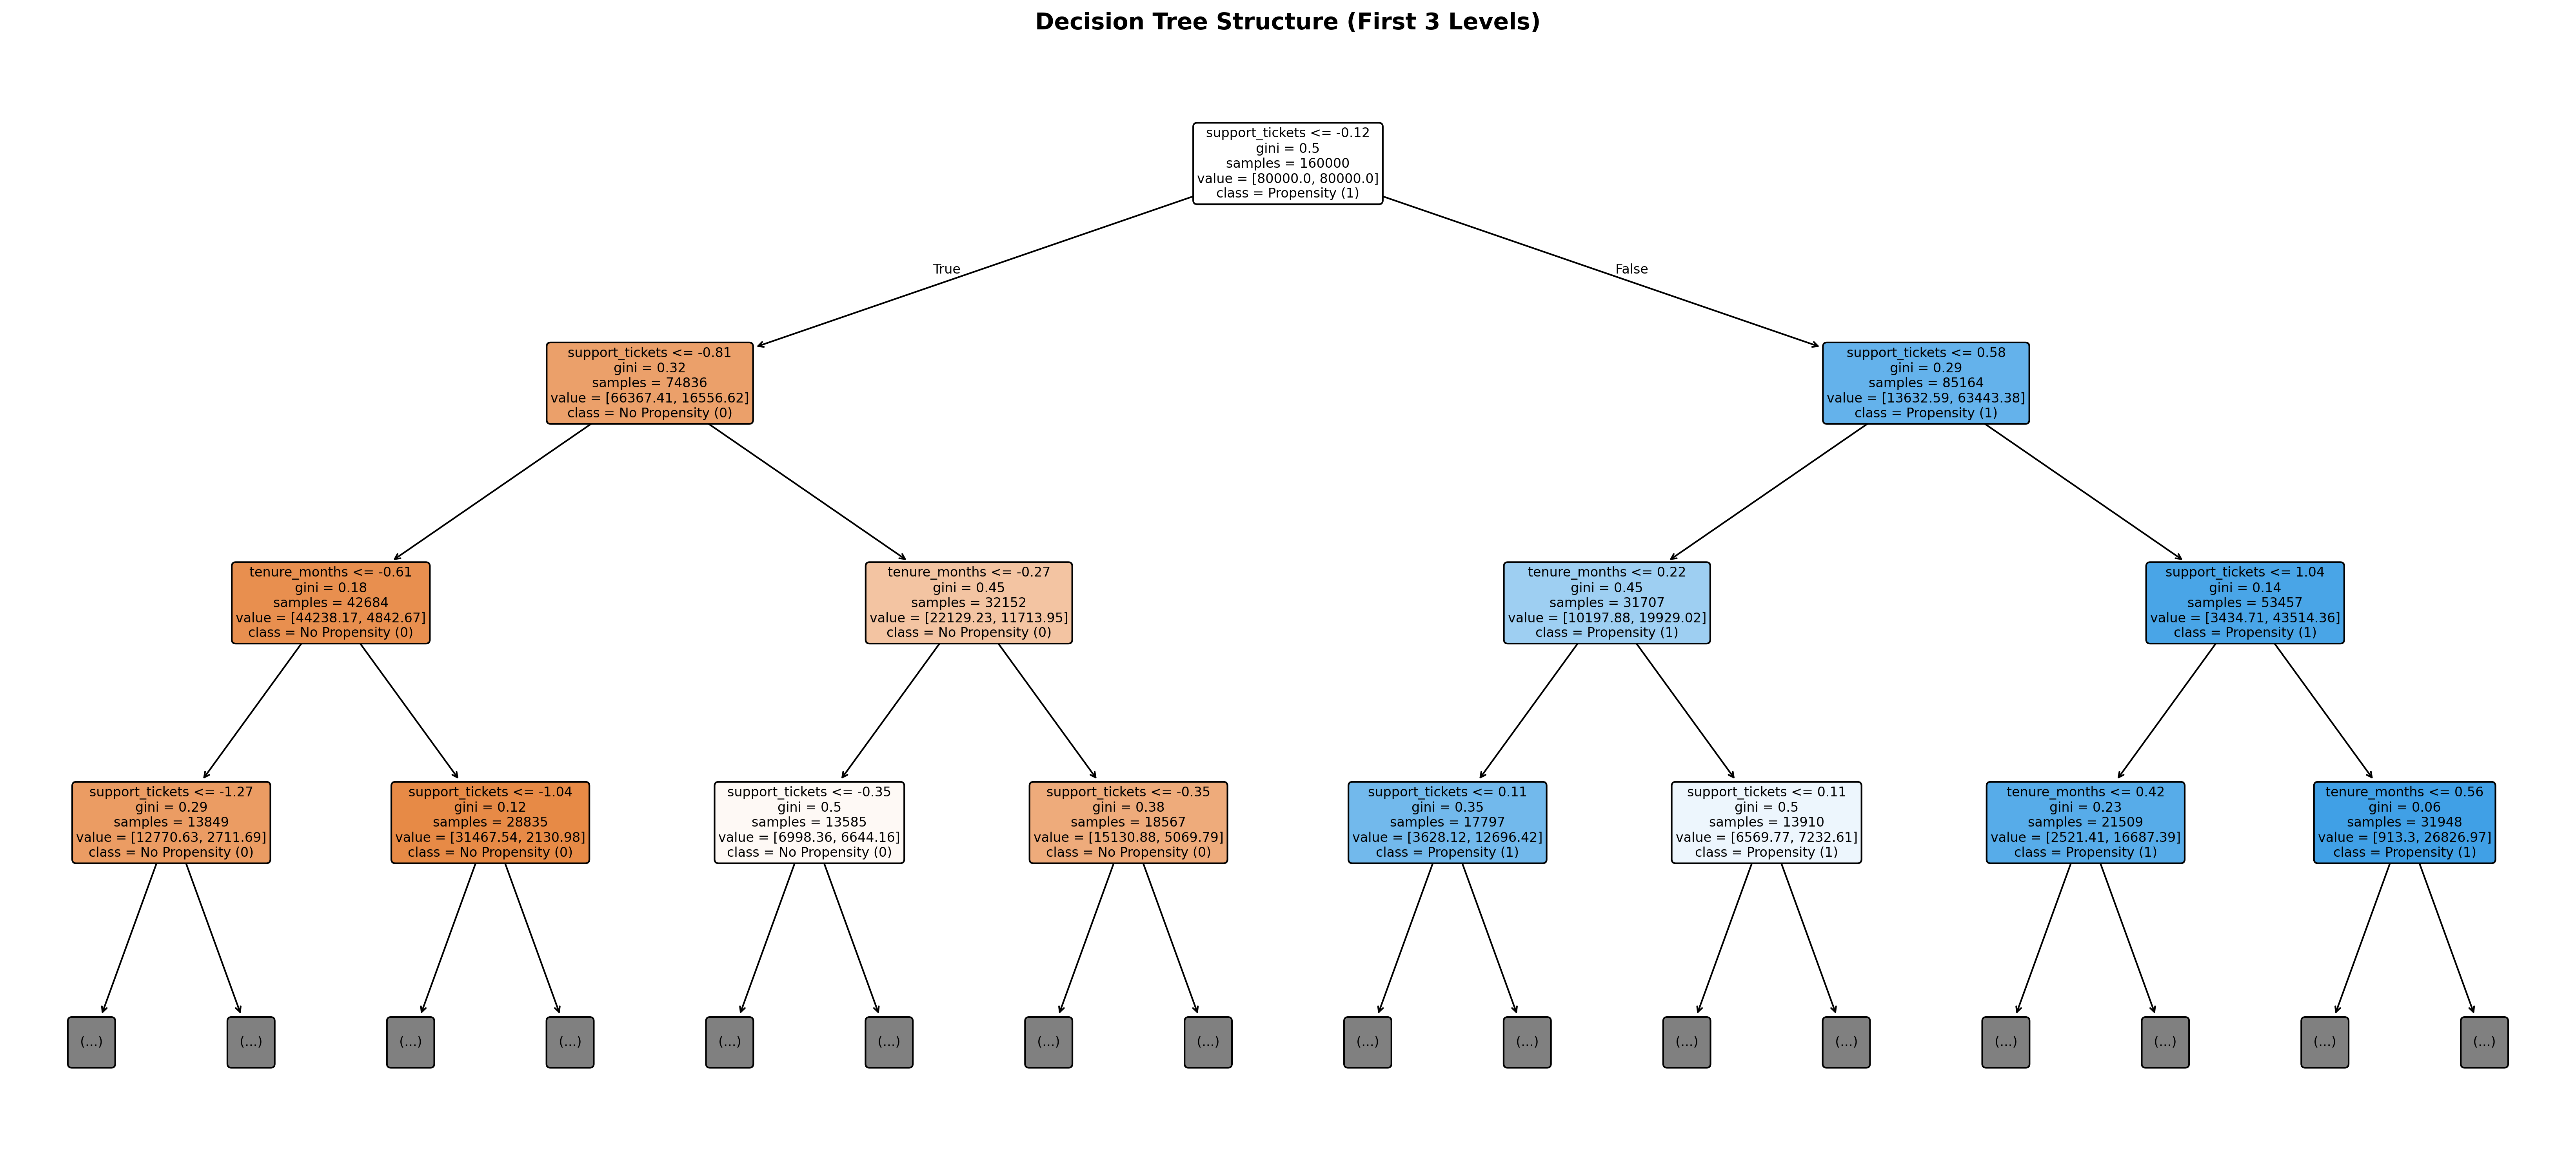

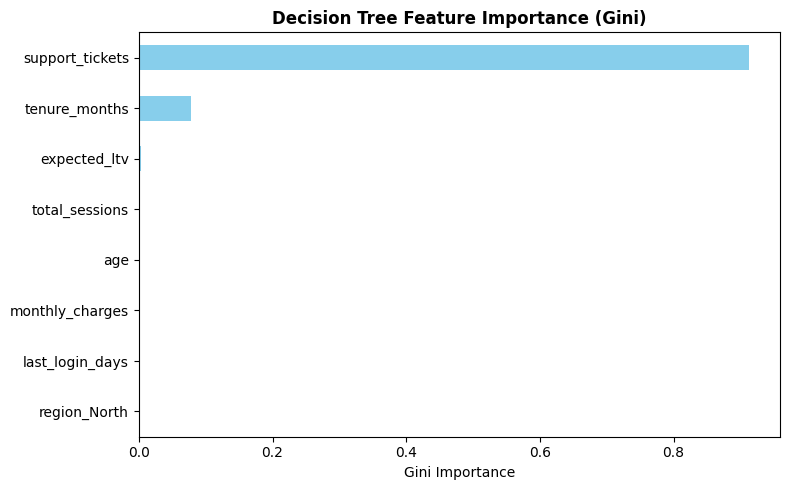

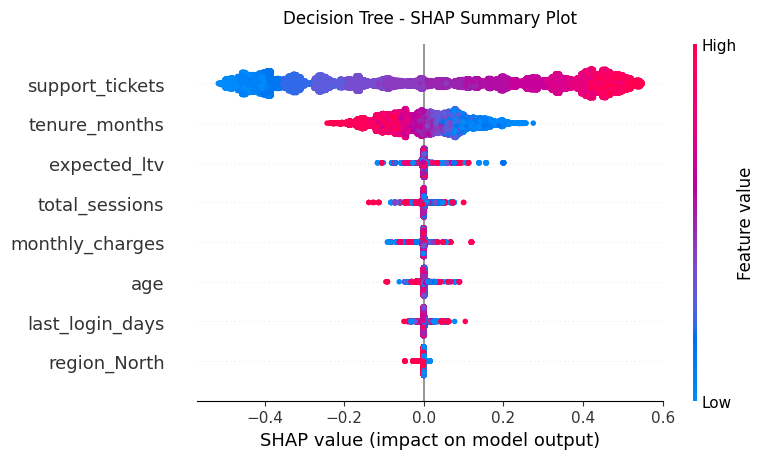

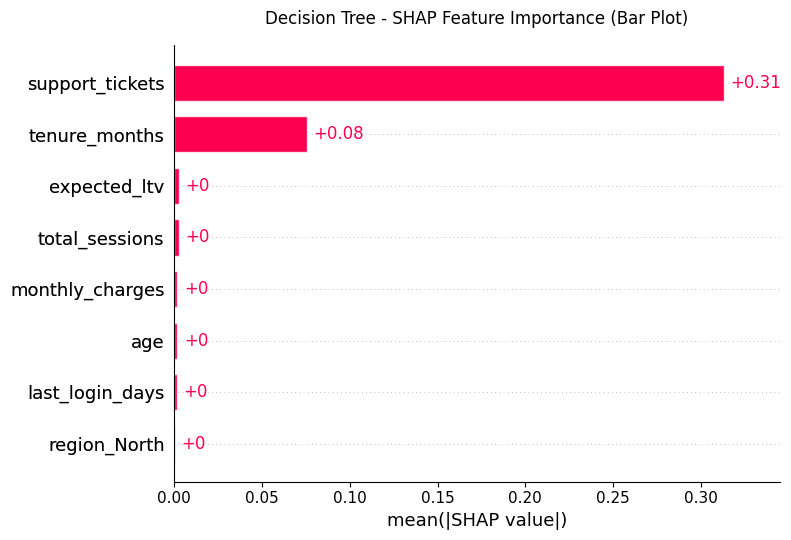

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,1.0,1
183691,1,0.9897329172325423,1
190416,1,0.9897329172325423,1
97505,1,0.8626650575224692,1
177223,0,0.7628015648937403,1
181100,1,0.5865805515944748,1
3513,1,0.5925226188684256,1
118791,1,0.9933466744515299,1
129846,0,0.049248651426279925,0
115,1,0.8215848877894854,1


In [0]:
results_dt = fit_dt_churn_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    df=df,
    n_iter_search=20
)

df_test_predictions = results_dt['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

## Logistic Regression (ElasticNet)
---

In [0]:
def fit_logreg_churn_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    df: pd.DataFrame,
    target_col: str = None,
    id_col: str = None,
    class_weight: str | dict | None = 'balanced',
    threshold_fs: str = 'median',
    n_iter_search: int = 20,
    cv_splits: int = 5,
    random_state: int = 42
) -> dict:

    # Use global variables if not provided
    if target_col is None:
        target_col = globals().get('target_col', 'churn')
    if id_col is None:
        id_col = globals().get('id_col', 'customer_id')
    
    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Model Algorithm: Logistic Regression (ElasticNet)")
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    imbalance_ratio = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Class distribution in Train -> Negative (0): {num_neg:,} | Positive (1): {num_pos:,}")
    print(f"- Calculated imbalance ratio (neg/pos): {imbalance_ratio:.2f}:1")
    print(f"- Logistic Regression Class weight strategy: Optimized by Optuna")

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # FEATURE SELECTION ONCE (BEFORE OPTUNA)
    print("\n--- Pre-selecting features (one-time, before optimization) ---")
    fs_model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=1.0,
        l1_ratio=0.5,
        max_iter=500,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1
    )
    
    fs_selector = SelectFromModel(
        estimator=fs_model,
        threshold=threshold_fs
    )
    
    fs_selector.fit(X_train, y_train)
    
    selected_mask = fs_selector.get_support()
    all_feature_names = X_train.columns.tolist()
    selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
    removed_features = [f for f, s in zip(all_feature_names, selected_mask) if not s]
    
    print(f" - Features selected: {len(selected_features)}/{len(all_feature_names)}")
    
    # TRANSFORM ONCE
    X_train_sel = pd.DataFrame(fs_selector.transform(X_train), columns=selected_features, index=X_train.index)
    X_test_sel = pd.DataFrame(fs_selector.transform(X_test), columns=selected_features, index=X_test.index)
    
    # OPTUNA OBJECTIVE FUNCTION (NO FEATURE SELECTION INSIDE)
    def objective(trial):
        params = {
            'C': trial.suggest_categorical('C', [0.01, 0.1, 1.0, 10.0]),
            'l1_ratio': trial.suggest_categorical('l1_ratio', [0.0, 0.5, 1.0]),
            'max_iter': trial.suggest_categorical('max_iter', [500, 1000]),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
        
        # CREATE MODEL (NO PIPELINE)
        model = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            random_state=random_state,
            n_jobs=-1,
            **params
        )
        
        # MANUAL CV LOOP FOR PRUNING (ON PRE-SELECTED FEATURES)
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_sel, y_train)):
            X_fold_train, X_fold_val = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, model.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='logistic_regression_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 15}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS (ON PRE-SELECTED FEATURES)
    best_model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        random_state=random_state,
        n_jobs=-1,
        **best_params
    )
    
    best_model.fit(X_train_sel, y_train)

    print("\n")
    print(" 3. FEATURE SELECTION (LOGISTIC REGRESSION)")
    print("=" * 60)
    print(f" - Initial Predictor Features: {len(all_feature_names)}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # PROBABILITIES
    probs_train = best_model.predict_proba(X_train_sel)[:, 1]
    probs_test = best_model.predict_proba(X_test_sel)[:, 1]

    # OPTIMAL THRESHOLD
    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. LOGISTIC REGRESSION EVALUATION & OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score (calculated on Train): {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary (Propensity Model - Logistic Regression) ---")
    print(metrics_df.round(4))

    # EVALUATION METRICS (ROC, PR, CONFUSION MATRIX)
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Logistic Regression (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - Logistic Regression (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Logistic Regression (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('logreg_evaluation_metrics_summary.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # FEATURE COEFFICIENTS (LOGISTIC REGRESSION)
    coefficients = pd.Series(best_model.coef_[0], index=selected_features, name='Coefficient')
    coefficients_abs = coefficients.abs().sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    coefficients_abs.tail(15).plot(kind='barh', color='steelblue')
    plt.title('Logistic Regression Feature Importance (Absolute Coefficients)', fontsize=12, fontweight='bold')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.savefig('logreg_feature_coefficients.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    return {
        'best_pipeline': None,  # No pipeline used (feature selection done once)
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'coefficients': coefficients,
        'coefficients_abs': coefficients_abs
    }

 1. DATASET INFORMATION AND IMBALANCE RATIO
- Model Algorithm: Logistic Regression (ElasticNet)
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Class distribution in Train -> Negative (0): 67,010 | Positive (1): 92,990
- Calculated imbalance ratio (neg/pos): 0.72:1
- Logistic Regression Class weight strategy: Optimized by Optuna


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)

--- Pre-selecting features (one-time, before optimization) ---


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-08-12 05:36:18,246] A new study created in memory with name: logistic_regression_propensity_optimization


 - Features selected: 8/16


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-12 05:36:22,591] Trial 0 finished with value: 0.8509459342319495 and parameters: {'C': 0.1, 'l1_ratio': 0.0, 'max_iter': 500, 'class_weight': None}. Best is trial 0 with value: 0.8509459342319495.
[I 2026-08-12 05:36:26,805] Trial 1 finished with value: 0.8509826158617658 and parameters: {'C': 0.01, 'l1_ratio': 1.0, 'max_iter': 500, 'class_weight': None}. Best is trial 1 with value: 0.8509826158617658.
[I 2026-08-12 05:36:31,784] Trial 2 finished with value: 0.8509333804568561 and parameters: {'C': 10.0, 'l1_ratio': 1.0, 'max_iter': 1000, 'class_weight': None}. Best is trial 1 with value: 0.8509826158617658.
[I 2026-08-12 05:36:36,216] Trial 3 finished with value: 0.8430240720573792 and parameters: {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 1000, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8509826158617658.
[I 2026-08-12 05:36:40,779] Trial 4 finished with value: 0.850944299732333 and parameters: {'C': 0.1, 'l1_ratio': 1.0, 'max_iter': 1000, 'class_weight': None}

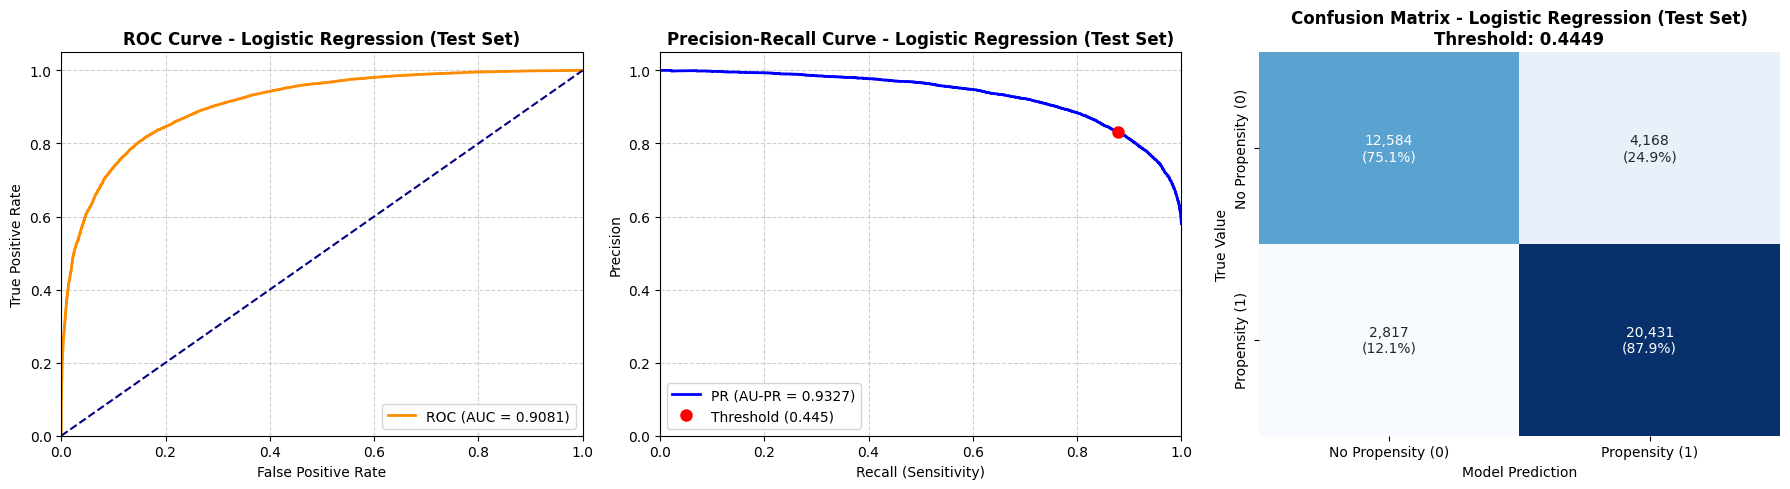

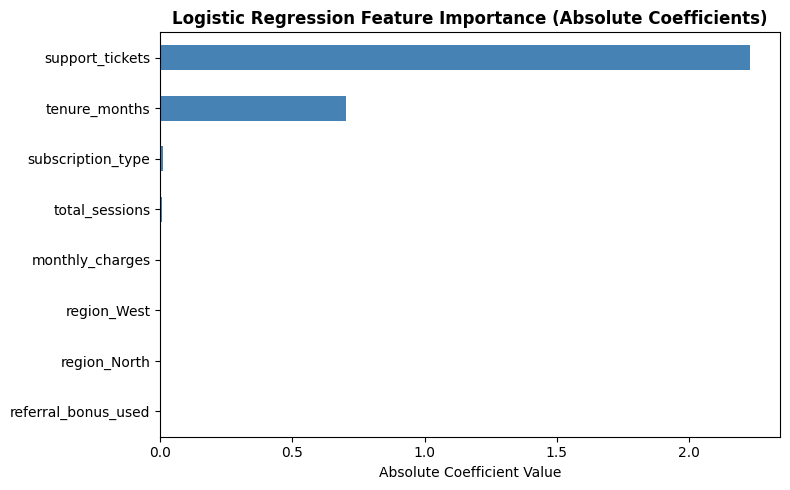

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,0.9940032406856688,1
183691,1,0.9751356153488231,1
190416,1,0.984696475974813,1
97505,1,0.9136180598866722,1
177223,0,0.845291508817727,1
181100,1,0.6996000430372924,1
3513,1,0.6620849012661616,1
118791,1,0.983315215611774,1
129846,0,0.09212641202951122,0
115,1,0.8711282657000173,1


In [0]:
results_logreg = fit_logreg_churn_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    df=df,
    n_iter_search=15
)

df_test_predictions = results_logreg['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

---
## Final Model Comparison and Recommendation
---

In [0]:
def compare_models_and_recommend(
    model_results: dict,
    total_features: int = 16
) -> pd.DataFrame:
    
    # PREPARE COMPARISON DATA FROM ALL MODELS
    comparison_data = []
    
    for model_name, results in model_results.items():
        test_metrics = results['metrics'].loc['Test']
        comparison_data.append({
            'Model': model_name,
            'Test F1': test_metrics['F1-Score (Opt)'],
            'Test AUC-ROC': test_metrics['AUC-ROC'],
            'Test Precision': test_metrics['Precision'],
            'Test Recall': test_metrics['Recall'],
            'Test Accuracy': test_metrics['Accuracy'],
            'Test AU-PR': test_metrics['AU-PR'],
            'CV F1': results['cv_f1_score_mean'],
            'Features': len(results['selected_features']),
            'Threshold': results['optimal_threshold'],
            'Best Params': results['best_params']
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Test F1', ascending=False).reset_index(drop=True)
    
    print(" " + "="*78 + " ")
    print("MODEL COMPARISON - TEST SET PERFORMANCE")
    print(" " + "="*78 + " ")
    print()
    print(df_comparison.round(4).to_string(index=False))
    print()
    print(" " + "="*78 + " ")
    
    # VISUAL COMPARISON PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # F1 VS AUC SCATTER PLOT
    ax1 = axes[0]
    for idx, row in df_comparison.iterrows():
        ax1.scatter(row['Test AUC-ROC'], row['Test F1'], s=200, alpha=0.7, label=row['Model'])
        ax1.annotate(row['Model'], 
                     (row['Test AUC-ROC'], row['Test F1']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax1.set_xlabel('AUC-ROC (Test)', fontweight='bold')
    ax1.set_ylabel('F1-Score (Test)', fontweight='bold')
    ax1.set_title('Performance Trade-off: F1 vs AUC-ROC', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.900, 0.912)
    ax1.set_ylim(0.850, 0.856)
    
    # BAR CHART COMPARISON
    ax2 = axes[1]
    metrics_to_plot = ['Test F1', 'Test Precision', 'Test Recall']
    df_plot = df_comparison.set_index('Model')[metrics_to_plot]
    df_plot.plot(kind='bar', ax=ax2, width=0.75, edgecolor='black', linewidth=0.8)
    ax2.set_ylabel('Score', fontweight='bold')
    ax2.set_title('Key Metrics Comparison', fontsize=12, fontweight='bold')
    ax2.legend(title='Metric', loc='center left', bbox_to_anchor=(1, 0.5))
    ax2.set_ylim(0.80, 0.90)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('model_comparison_final.png', dpi=300, bbox_inches='tight')
    plt.show()
    print()
    
    # PRINT DIRECT RECOMMENDATION
    print(" " + "="*78 + " ")
    print("RECOMMENDATION")
    print(" " + "="*78 + " ")
    print()
    
    top_model = df_comparison.iloc[0]
    print(f"Go with: {top_model['Model']}")
    print()
    print("Stats:")
    print(f"  • Test F1: {top_model['Test F1']:.4f}")
    print(f"  • Test Accuracy: {top_model['Test Accuracy']:.4f}")
    print(f"  • AUC-ROC: {top_model['Test AUC-ROC']:.4f}")
    print(f"  • AU-PR: {top_model['Test AU-PR']:.4f}")
    print(f"  • Precision: {top_model['Test Precision']:.4f}")
    print(f"  • Recall: {top_model['Test Recall']:.4f}")
    print(f"  • Selected features: {top_model['Features']}/{total_features}")
    print(f"  • Optimal threshold: {top_model['Threshold']:.4f}")
    print()
    print("Optimal Hyperparameters:")
    for param, value in top_model['Best Params'].items():
        print(f"  • {param}: {value}")
    print(" " + "="*78 + " ")
    
    return df_comparison

MODEL COMPARISON - TEST SET PERFORMANCE

              Model  Test F1  Test AUC-ROC  Test Precision  Test Recall  Test Accuracy  Test AU-PR  CV F1  Features  Threshold                                                                                                                                                                               Best Params
            XGBoost   0.8546        0.9079          0.8261       0.8852         0.8249      0.9325 0.8421         8     0.3485                                                {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 3, 'gamma': 0}
Logistic Regression   0.8540        0.9081          0.8306       0.8788         0.8254      0.9327 0.8510         8     0.4449                                                                                                                       {'C': 0.01, 'l1_ratio': 1.0, 'max_iter': 500, 'class_weight': None}
           LightGBM 

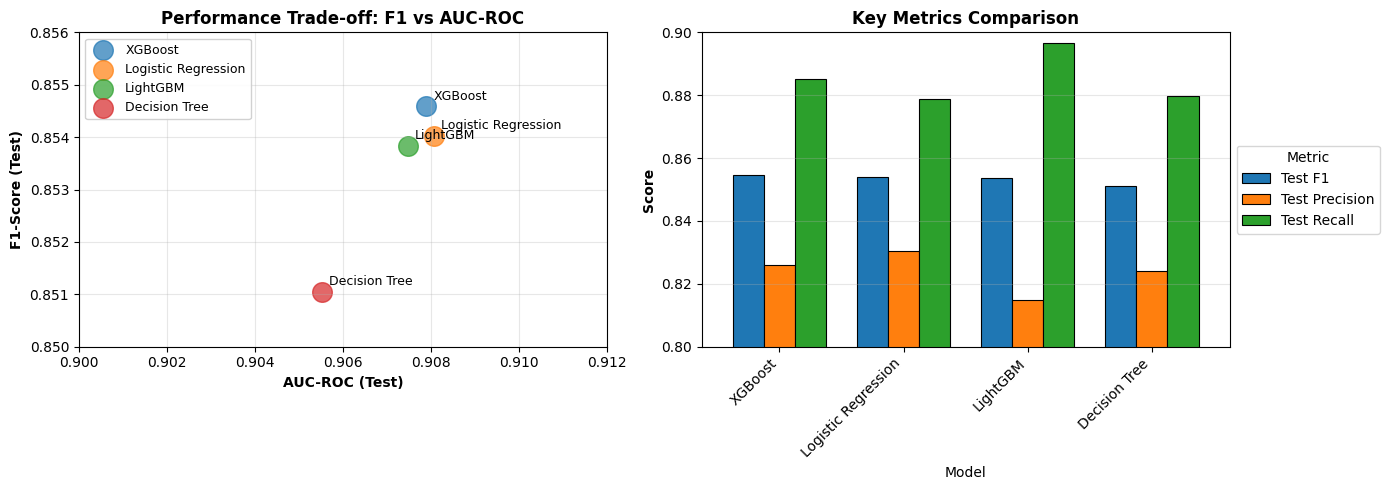


RECOMMENDATION

Go with: XGBoost

Stats:
  • Test F1: 0.8546
  • Test Accuracy: 0.8249
  • AUC-ROC: 0.9079
  • AU-PR: 0.9325
  • Precision: 0.8261
  • Recall: 0.8852
  • Selected features: 8/16
  • Optimal threshold: 0.3485

Optimal Hyperparameters:
  • n_estimators: 300
  • max_depth: 3
  • learning_rate: 0.05
  • subsample: 1.0
  • colsample_bytree: 0.6
  • min_child_weight: 3
  • gamma: 0


In [0]:
# Prepare model results dictionary
model_results = {
    'XGBoost': results_xgboost,
    'LightGBM': results_lgbm,
    'Decision Tree': results_dt,
    'Logistic Regression': results_logreg
}

# Generate comparison 
df_comparison = compare_models_and_recommend(
    model_results=model_results,
    total_features=16
)